# Iran war risk and global financial markets in 2026

**Panagiotis Housos · ph2606**  
FRE-GY 7871A · NLP and the Investment Process · Assignment 3  
Observation cutoff: **16 September 2026**. Prepared 19 September 2026.  
This notebook contains saved outputs. Follow the README to acquire the local inputs before executing it.

## 1. Research question and principal finding

How do global financial markets respond to news about the duration and physical consequences of the Iran war? Before fighting, news changes the chance of conflict; during an ongoing war, it also changes expectations of an early halt, prolonged disruption, renewed fighting and the severity of supply losses. Those are distinct from the emotional tone of an article.

The study first implements the uncentered second-moment and instrumental-variable method in Rigobon and Sack’s *The Effects of War Risk on U.S. Financial Markets*, preserving the purposes of their Tables 1, 2 and 3. It then evaluates a duration-related news alternative. The observation window is **1 January–16 September 2026**, with actual market endpoints disclosed below. The source-cited chronology contains 25 developments on 24 US sessions; fitted Treasury availability leaves 23 major-news sessions and 23 nearest comparison sessions in the main estimation.

The observed oil movement is large: WTI spot rises **87.07%**, Brent **111.04%**, and Brent minus WTI widens from **$4.77 to $23.78 per barrel**. These full-period changes cannot be attributed entirely to the war. All 19 available sensitivity rows have an uncertain reference-variance shift; the identifying restrictions do not support a reliable causal hedge ratio. Separate news regressions also require caution: none of 48 forward-response coefficients survives the multiple-test adjustment, while five of 16 prior-return timing checks do. Markets often move before the daily news archive becomes available.

The investment implication is to keep exposure diversified and use a limited short-duration liquidity allocation, rather than treat these estimated ratios as executable oil or bond trading signals. The social appendix studies 403 retrieved Trump Truth Social text candidates, explicitly distinguishes Truth Social from X, and examines targets, conditions, attribution and publication timing without treating generic sentiment as an end-of-war probability.

In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
assert (ROOT/'src').is_dir(), 'Execute from the repository root.'
sys.path.insert(0, str(ROOT))
OUT = ROOT/'outputs'
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 18)
pd.options.display.float_format = '{:,.4f}'.format
required = ['market_levels.csv','offrun_yields.csv','news_documents.csv',
            'social_candidates.csv','gdelt_iran_events.csv']
assert all((ROOT/'data/processed'/p).exists() for p in required), 'Run README acquisition steps first.'
from src.text_features import build as build_text
from src.social_audit import main as audit_social
from src.social_timing import build as build_social_timing
from src.duration_news import build as build_duration
from src.iran_study import run
from src.study_figures import build as build_figures
build_text()
audit_social()
social_audit, social_calendar, social_sessions, social_summary = build_social_timing()
headlines, gdelt_sources, duration_daily, duration_summary = build_duration()
diagnostics = run(bootstrap=1999)
build_figures()
for name, digest in diagnostics['input_sha256'].items():
    assert hashlib.sha256((ROOT/name).read_bytes()).hexdigest() == digest, name
t1 = pd.read_csv(OUT/'paper_table1.csv')
t2 = pd.read_csv(OUT/'paper_table2.csv')
t3 = pd.read_csv(OUT/'paper_table3.csv')
print('Analysis recomputed from cached inputs; source hashes verified.')

{
  "eligible_news_documents": 1029,
  "within_cutoff_documents": 1025,
  "war_relevant_documents": 917,
  "numeric_text_eligible": 218,
  "modified_after_cutoff": 4,
  "mapped_effective_date": 1025,
  "scoring_target": "Unquoted physical conflict/economic context after paragraph-level official-subject, policy and attribution exclusions, plus sentence-level personal-anaphora exclusions. Attention counts independently retain all relevant articles.",
  "limits": "Conservative heuristic exclusions can omit factual reporting and cannot guarantee semantic separation; no independent labeled accuracy; financial LM vocabulary transferred to news; current revised text. Absence of eligible text yields a missing value, not neutrality.",
  "idf": "Full eligible news corpus, retrospective; no prediction claim."
}


{
  "candidate_rows_audited": 403,
  "candidate_ids_match_independent_raw_retrieval": true,
  "all_text_and_local_dates_match_raw_snapshot": true,
  "candidate_csv_sha256": "addb2f87477ebccf8867dce3916e417bc8c09420beb75c800968872ac26d2781",
  "archive_sha256": "6481b8a27413428bcf09c48c30ef48b3d807c44c2176917a7be0a8a1f0d6b4a1",
  "source_form_counts": {
    "Text without URL or explicit attribution prefix": 258,
    "Text plus URL": 95,
    "Explicit RT marker": 43,
    "Explicit attribution prefix": 4,
    "URL only": 3
  },
  "relevance_match_location_counts": {
    "Body": 327,
    "Body and URL": 65,
    "URL only": 11
  },
  "explicit_repost_marker_records": 43,
  "explicit_self_repost_prefix_records": 31,
  "explicit_attribution_prefix_records": 4,
  "url_only_records": 3,
  "records_with_urls": 109,
  "records_with_unreviewed_media": 16,
  "empty_text_records_with_media_in_full_2026_window": 1894,
  "candidate_records_with_identical_text_other_id": 26,
  "unique_candidate_texts":

{
  "candidate_records": 403,
  "equity_state_counts": {
    "open": 128,
    "weekend": 101,
    "after_close": 82,
    "pre_open": 81,
    "holiday": 11
  },
  "friday_to_sunday_posts": 161,
  "reaction_close_without_observed_price": 0,
  "claim_cue_record_counts": {
    "ceasefire_truce": 15,
    "negotiations_agreement": 111,
    "cessation_cancellation": 18,
    "continuation_extension": 33,
    "strikes_military": 162,
    "shipping_blockade": 122,
    "nuclear": 85,
    "energy_prices": 63,
    "trade_sanctions": 19,
    "humanitarian_civilian": 18
  }
}


Main paper method: 23 H and 23 L sessions


{
  "cutoff": "2026-09-16",
  "created_utc": "2026-09-19T21:18:43.060043+00:00",
  "main_curve": "Federal Reserve GSW fitted off-the-run coupon-equivalent par yields",
  "curve_last_date": "2026-09-11",
  "event_records": 25,
  "event_sessions": 24,
  "main_pairs": 23,
  "no_major_event_sessions": 153,
  "equity_sessions": 177,
  "main_weak_rows": 19,
  "main_available_outcomes": 19,
  "rank_one_residual": 0.6071911994201908,
  "lp_primary_tests": 48,
  "lp_primary_q_lt05": 0,
  "lp_placebo_q_lt05": 5
}


Analysis recomputed from cached inputs; source hashes verified.


## 2. Data and the replication boundary

The reference papers are [Rigobon and Sack (2003), NBER Working Paper 9609](https://www.nber.org/papers/w9609) and [Rigobon (2003), Review of Economics and Statistics 85(4), 777–792](https://doi.org/10.1162/003465303772815727). The first studies the period before the Iraq invasion; its broader sample contains 47 business days and 17 selected news days. Its latent factor also includes other security news. The second explains why changes in relative structural-shock variances can identify simultaneous systems, subject to stable coefficients and appropriate restrictions on common shocks. Robust standard errors alone do not provide that identification.

The main reference is the Federal Reserve’s fitted two-year off-the-run **par yield**, paired with the fitted ten-year par yield (`SVENPY02` and `SVENPY10`). These Gürkaynak–Sack–Wright research estimates exclude on-the-run and first-off-the-run notes and bonds; they are a closer conceptual match to the paper than constant-maturity Treasury yields, but are revisable model estimates. The downloaded fitted curve ends on **11 September**. [Federal Reserve curve documentation](https://www.federalreserve.gov/data/nominal-yield-curve.htm).

FRED/EIA spot oil and Treasury constant-maturity yields end on 15 September; the broad dollar ends on 11 September; most exchange-traded series end on 16 September. No missing observation is forward-filled. Every one-session paired outcome must share the current and preceding US session with the reference. Incomplete pairs are removed for that outcome, so some rows have fewer than 23 pairs. Prices use simple returns, $100(P_t/P_{t-1}-1)$; yields, breakevens and credit spreads use **percentage-point changes**; dollar oil and the physical spread use dollars per barrel. Thus 0.25 percentage points equals 25 basis points.

The original 12-month oil futures contract, spot gold dollar series and ten-year traded liquidity premium are not reproduced with identical instruments. Nearby WTI futures, GLD percentage returns and credit OAS are disclosed proxies. The liquidity-premium row remains unavailable: subtracting one modeled yield curve from another would not recover the traded premium. EFA and EEM represent USD fund returns, combining overseas equity and currency exposure. DXY and the Fed broad dollar have different baskets. These boundaries matter when comparing the tables with 2003.

In [2]:
market_manifest = json.loads((ROOT/'data/raw/market/manifest.json').read_text())
display(pd.DataFrame(market_manifest['series'])[['series','provider','first','last','observations_2026']])
fitted = pd.read_csv(ROOT/'data/processed/offrun_yields.csv', index_col=0)
display(fitted.tail())
display(pd.DataFrame([
 ['Treasury yields','Fitted off-the-run par yields','GSW par yields; CMT robustness'],
 ['Oil','12-month futures, dollars','Nearby WTI dollars; WTI/Brent spot and nearby percentages'],
 ['Gold','Dollar gold price','GLD fund percentage return'],
 ['Credit','BBB/high-yield Treasury spreads','BBB/high-yield option-adjusted spreads'],
 ['Liquidity','Traded on-the-run premium','Unavailable'],
], columns=['Market','Original paper','Public-data implementation']))

,series,provider,first,last,observations_2026
0,DCOILWTICO,FRED,2025-12-15,2026-09-15,176
1,DCOILBRENTEU,FRED,2025-12-15,2026-09-15,178
2,DGS2,FRED,2025-12-15,2026-09-15,177
3,DGS10,FRED,2025-12-15,2026-09-15,177
4,DGS3MO,FRED,2025-12-15,2026-09-15,177
5,T10YIE,FRED,2025-12-15,2026-09-16,178
6,BAMLC0A4CBBB,FRED,2025-12-15,2026-09-16,187
7,BAMLH0A0HYM2,FRED,2025-12-15,2026-09-16,187
8,DTWEXBGS,FRED,2025-12-15,2026-09-11,175
9,CL=F,Yahoo Finance,2025-12-15,2026-09-16,177


,SVENPY02,SVENPY10
Date,,
2026-09-07,NaN,NaN
2026-09-08,4.4044,4.8440
2026-09-09,4.4351,4.8571
2026-09-10,4.5736,4.9810
2026-09-11,4.6405,4.9922


,Market,Original paper,Public-data implementation
0,Treasury yields,Fitted off-the-run par yields,GSW par yields; CMT robustness
1,Oil,"12-month futures, dollars",Nearby WTI dollars; WTI/Brent spot and nearby ...
2,Gold,Dollar gold price,GLD fund percentage return
3,Credit,BBB/high-yield Treasury spreads,BBB/high-yield option-adjusted spreads
4,Liquidity,Traded on-the-run premium,Unavailable


## 3. WTI, Brent, global assets and the yield curve

WTI spot increases from $57.21 on 2 January to $107.02 on 15 September; Brent increases from $61.98 to $130.80. Define the physical spread as $S_t=P_t^{Brent}-P_t^{WTI}$ and the relative Brent premium as $100(P_t^{Brent}/P_t^{WTI}-1)$. The final dollar spread is $23.78, equivalent to **22.22% of WTI**, compared with 8.34% initially. The dollar spread ranges from −$2.45 to $25.94. A wide spread is not itself a calibrated war premium: quality, location, inventories, transport and refining demand also affect it.

On 15 September the two rolling nearby futures quotes differ by approximately $2.92, compared with the $23.78 spot difference. Those are different instruments and the rolling contracts can represent different delivery months. A tradable convergence strategy would require matched expiries and basis-risk analysis; mixing spot and futures would change the question. [EIA discussion of physical prices and contract timing](https://www.eia.gov/todayinenergy/detail.php?id=67424).

The S&P 500 gains 10.11% over its observed 2026 interval, EFA 9.94% and EEM 17.46%; GLD declines 1.64%. The two-year CMT yield rises from 3.47% to 4.67%, and the ten-year from 4.19% to 5.00%. The 10y-minus-2y curve therefore narrows from 0.72 to 0.33 percentage points: **39 basis points of bear flattening**. Yield changes are not bond returns. These trends motivate the investigation but include macroeconomic and other news; they do not measure the isolated contribution of war.

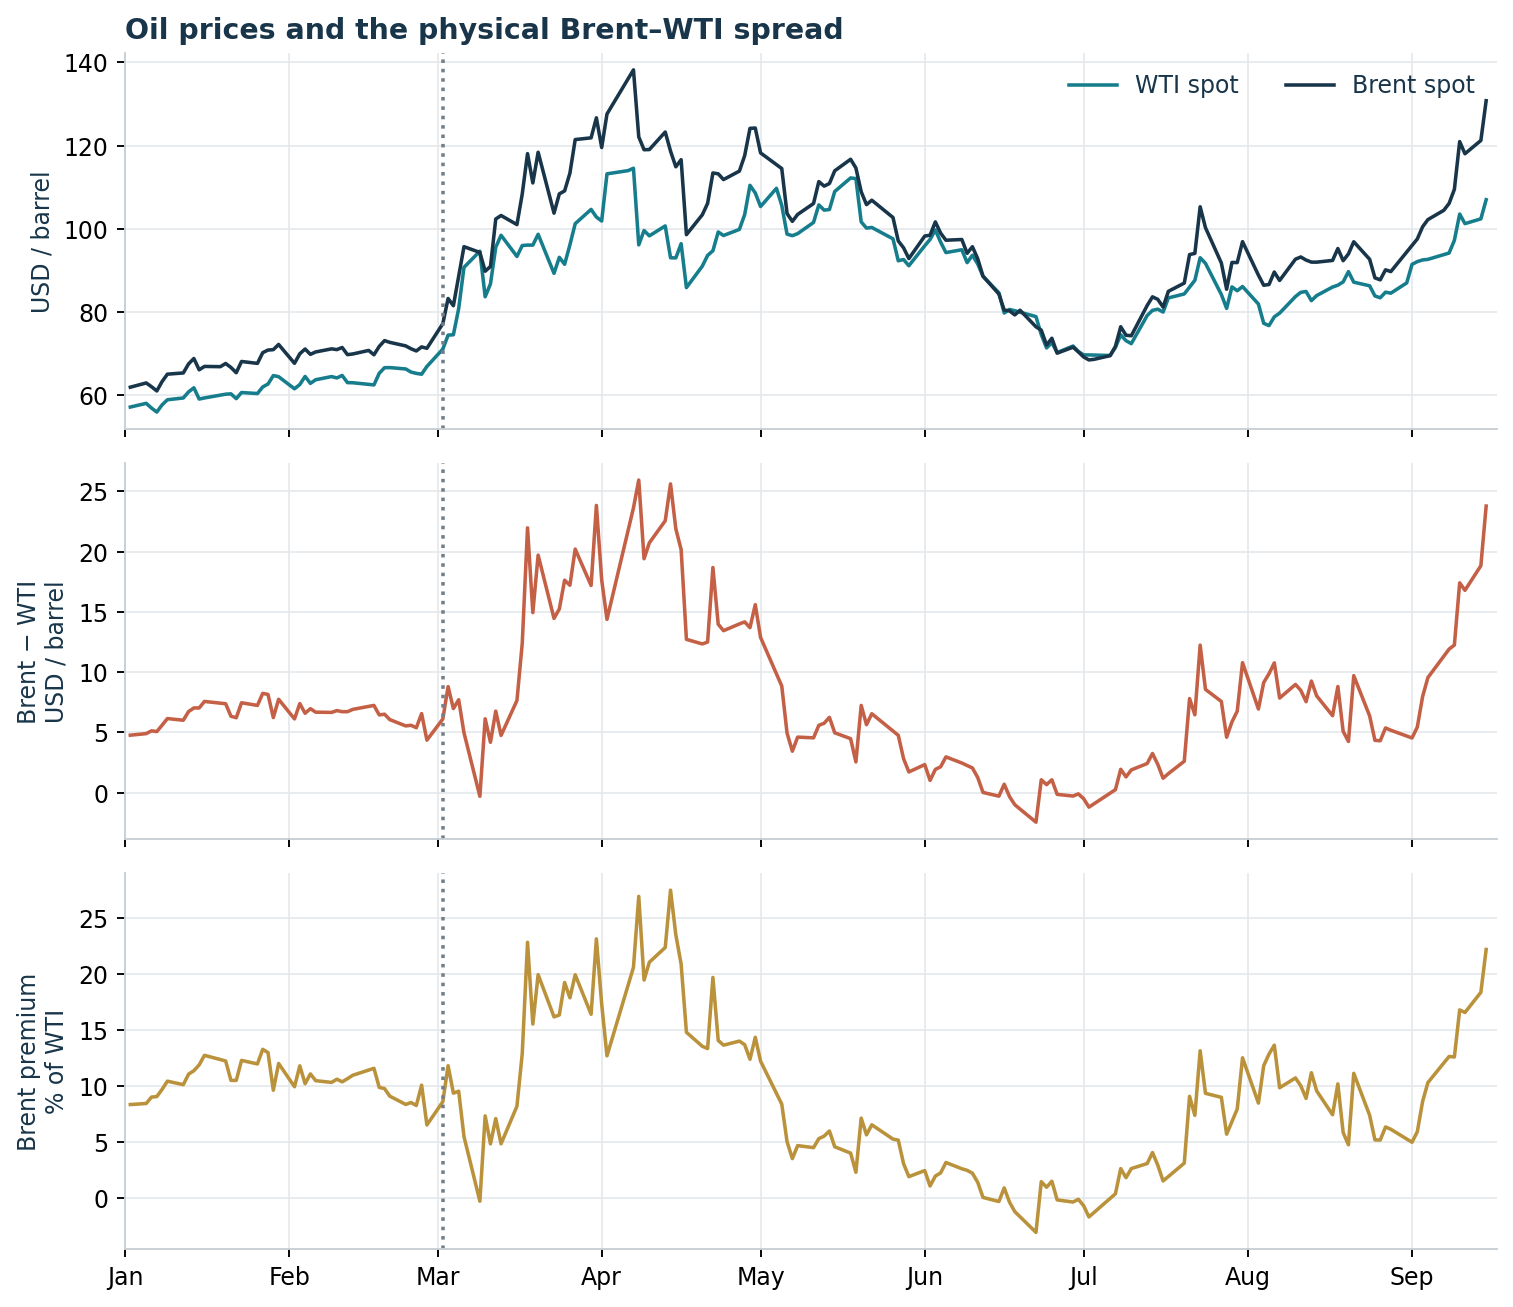

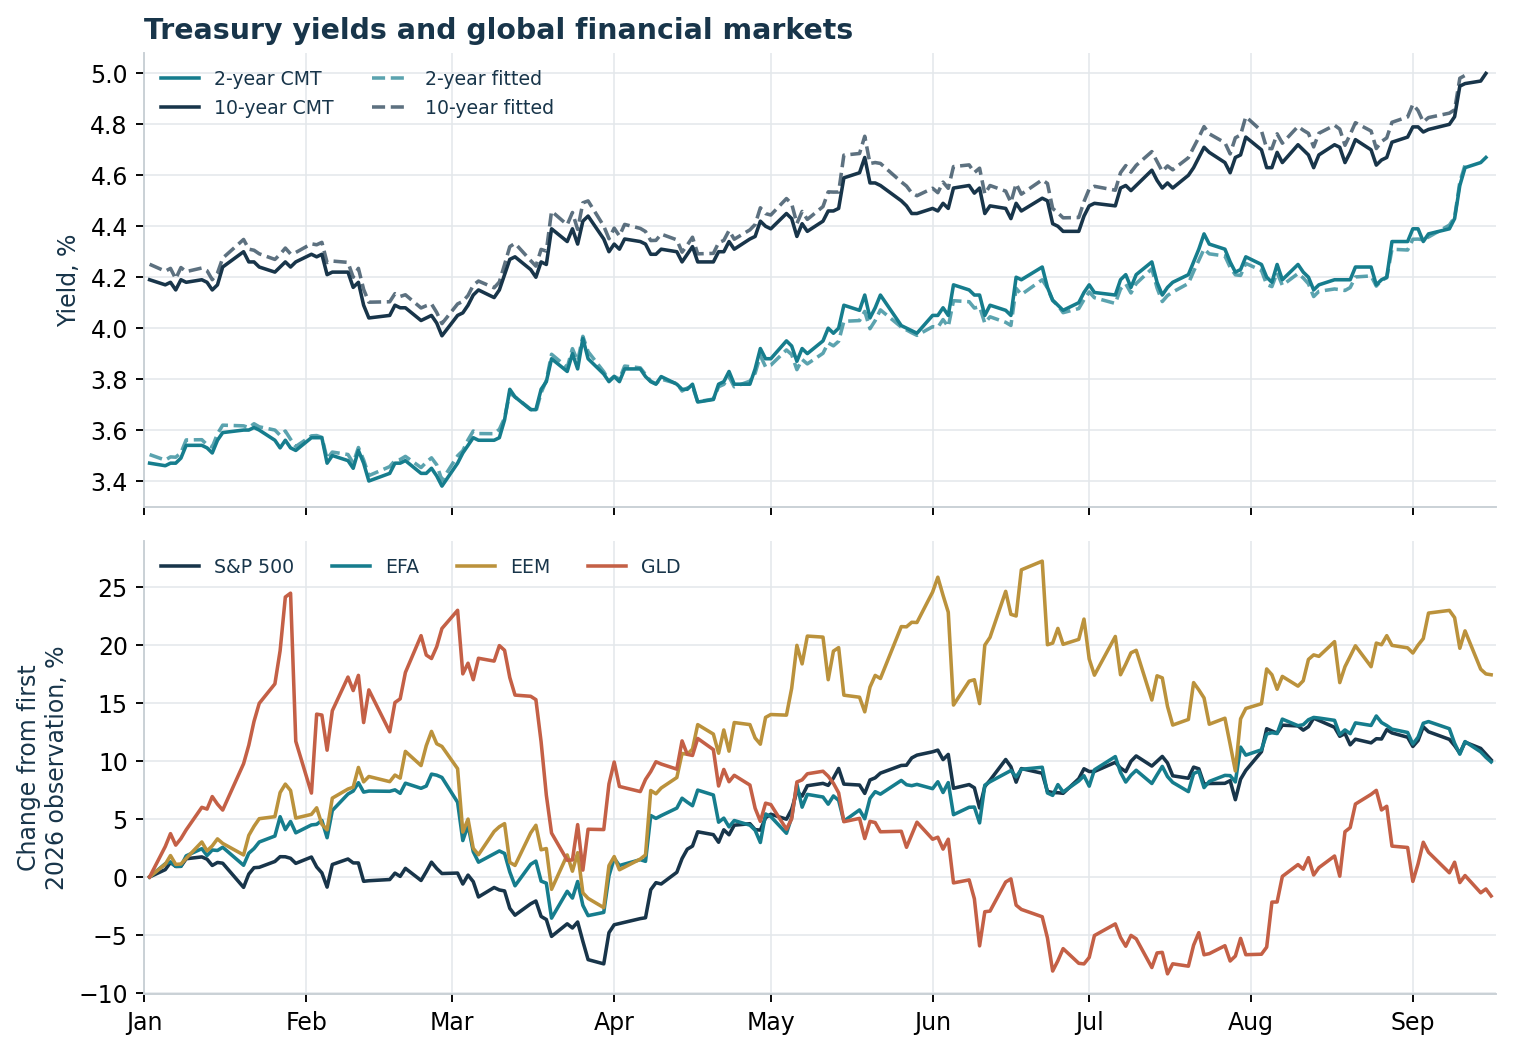

,Series,First date,Last date,First level,Last level,Change %
0,DCOILWTICO,2026-01-02,2026-09-15,57.2100,107.0200,87.0652
1,DCOILBRENTEU,2026-01-02,2026-09-15,61.9800,130.8000,111.0358
2,^GSPC_close,2026-01-02,2026-09-16,"6,858.4702","7,551.8101",10.1092
3,EFA,2026-01-02,2026-09-16,95.5283,105.0200,9.9360
4,EEM,2026-01-02,2026-09-16,55.9492,65.7200,17.4637
5,GLD,2026-01-02,2026-09-16,398.2800,391.7400,-1.6421


In [3]:
display(Image(filename=str(OUT/'study_oil.png')))
display(Image(filename=str(OUT/'study_markets.png')))
levels = pd.read_csv(ROOT/'data/processed/market_levels.csv', index_col=0, parse_dates=True).loc['2026-01-01':]
rows = []
for col in ['DCOILWTICO','DCOILBRENTEU','^GSPC_close','EFA','EEM','GLD']:
    x = levels[col].dropna()
    rows.append([col,str(x.index[0].date()),str(x.index[-1].date()),x.iloc[0],x.iloc[-1],100*(x.iloc[-1]/x.iloc[0]-1)])
display(pd.DataFrame(rows, columns=['Series','First date','Last date','First level','Last level','Change %']))

## 4. Original-paper method and Table 1: dated war news

Write the reduced form as $\Delta X_t=d w_t+u_t$. The war-factor loading in the two-year yield is normalized to one. If only the variance of the orthogonal war shock changes between major-news days $H$ and nearby comparison days $L$, with stable loadings and nuisance-shock moments, then

$$\Omega_H-\Omega_L=\delta dd',\qquad \delta>0.$$

This is a **positive rank-one restriction**, not simply a claim that markets are volatile during war. The original paper assumes zero-mean changes and uses uncentered mean squares. The implementation therefore uses uncentered moments and no intercept throughout the three IV specifications. For two-year change $x$ and outcome change $y$, define $a=E_H[x^2]-E_L[x^2]$, $b=E_H[xy]-E_L[xy]$ and $c=E_H[y^2]-E_L[y^2]$. Then $\widehat d_1=b/a$ and $\widehat d_2=c/b$. With equal group sizes, the instruments are $s_tx_t$ and $s_ty_t$, where $s_t=+1$ in $H$ and $-1$ in $L$. Pooled 2SLS uses both instruments jointly.

Table 1 performs the original chronology’s role: dates, source evidence and the information conveyed. The calendar is retrospective and nonexhaustive, selected from documented developments without filtering on return magnitude. Each distinct major-news session has $H_t=1$; other observed sessions have $H_t=0$. There are **24 H and 153 non-H sessions** in the full calendar. Each estimable H is matched without replacement to the nearest eligible non-H date by calendar distance, preferring the earlier date on a tie. This reproduces the paper’s nearby-comparison logic; it does not guarantee equal non-war volatility. The main fitted-curve window yields **23 H/L pairs**. The September 14 event is retained in the chronology but cannot enter that estimation.

The event-information labels distinguish prewar movements and negotiations, fighting, announced cessation and physical disruption. An announced ceasefire may alter expectations without establishing a durable end. No numerical end probability is inferred from these labels. The binary **major-news indicator** identifies a research regime, not the sign or magnitude of the war shock. In particular, H=0 means no event on this selected major-news list; it does not mean there was no Iran reporting that day.

In [4]:
display(t1[['event_date','weekday','market_date','cash_window','description','war_risk','included_in_main_estimation','source_url']])
display(pd.read_csv(OUT/'paper_matching.csv'))
design = pd.read_csv(OUT/'binary_news_days.csv')
display(design[['major_war_news_day','any_gdelt_war_news','any_guardian_war_news']].value_counts().rename('Sessions').reset_index())

,event_date,weekday,market_date,cash_window,description,war_risk,included_in_main_estimation,source_url
0,2026-01-14,Wednesday,2026-01-14,Intraday time uncertain,Some Al Udeid personnel advised to leave Qatar,Prewar force movement,True,https://www.investing.com/news/commodities-new...
1,2026-01-26,Monday,2026-01-26,12:19 ET report; open,USS Abraham Lincoln and accompanying warships ...,Prewar force movement,True,https://apnews.com/article/58e6da912f9167df94f...
2,2026-02-06,Friday,2026-02-06,Intraday time uncertain,Iran and United States hold indirect talks in ...,Prewar negotiations,True,https://apnews.com/article/32d621b98f7a3a68831...
3,2026-02-17,Tuesday,2026-02-17,Intraday time uncertain,United States and Iran hold Geneva nuclear talks,Prewar negotiations,True,https://www.investing.com/news/commodities-new...
4,2026-02-26,Thursday,2026-02-26,13:42 ET report; open,Geneva talks end with further negotiations ann...,Prewar negotiations,True,https://wtop.com/world/2026/02/omans-foreign-m...
5,2026-02-28,Saturday,2026-03-02,Weekend; closed,United States and Israel begin attacks on Iran,Fighting begins,True,https://apnews.com/article/04da58cbae991183f8b...
6,2026-03-18,Wednesday,2026-03-18,Intraday time uncertain,South Pars facilities attacked; Iran attacks G...,Energy facilities attacked,True,https://www.investing.com/news/world-news/iran...
7,2026-04-07,Tuesday,2026-04-08,18:32 ET announcement; closed,United States and Iran announce two-week cease...,Ceasefire announced,True,https://www.upi.com/Top_News/US/2026/04/07/Ira...
8,2026-04-12,Sunday,2026-04-13,Weekend; closed,Islamabad talks end without agreement,Talks inconclusive,True,https://apnews.com/article/04da58cbae991183f8b...
9,2026-04-13,Monday,2026-04-13,Intraday time uncertain,United States begins blockade of Iranian ports,Port blockade begins,True,https://apnews.com/article/04da58cbae991183f8b...


,high_date,low_date,status,distance_days
0,2026-01-14,2026-01-13,Matched,1.0000
1,2026-01-26,2026-01-27,Matched,1.0000
2,2026-02-06,2026-02-05,Matched,1.0000
3,2026-02-17,2026-02-18,Matched,1.0000
4,2026-02-26,2026-02-25,Matched,1.0000
5,2026-03-02,2026-03-03,Matched,1.0000
6,2026-03-18,2026-03-17,Matched,1.0000
7,2026-04-08,2026-04-07,Matched,1.0000
8,2026-04-13,2026-04-14,Matched,1.0000
9,2026-04-17,2026-04-16,Matched,1.0000


,major_war_news_day,any_gdelt_war_news,any_guardian_war_news,Sessions
0,0,1,1,134
1,1,1,1,23
2,0,1,0,19
3,1,1,0,1


## 5. Table 2: financial sensitivities under the paper’s normalization

Every effect below equals $-0.25\widehat d$: a hypothetical shock scaled to reduce the two-year fitted yield by **25 basis points**. Because $x$ is in percentage points, the multiplier is −0.25. This is a common reporting scale, not proof that an increase in Iran-war risk lowers yields. The original paper’s dollar-oil row is represented by explicitly labeled nearby WTI; spot oil percentage returns and other global assets are extensions.

Parentheses contain absolute HC1 IV t-statistics, using the no-intercept finite-sample correction. The source paper does not specify its covariance estimator in enough detail to reproduce that convention exactly; classical t-statistics are also retained in the notebook. Conventional IV t-statistics rely on adequate identification. **W marks every available row** because the 95% within-regime bootstrap interval for the reference second-moment shift includes zero. Bootstrap diagnostics use 1,999 independent resamples within H and L with a fixed seed; this is an explicitly chosen diagnostic, not a bootstrap recipe specified by the war paper or a weak-IV-robust confidence set. Unreliable ratio confidence intervals are withheld, while raw moments remain available.

The pooled ten-year response is **−0.153 percentage points**, compared with −0.26 in the 2003 paper. The two single-instrument estimates disagree even in sign. The pooled S&P response is **+4.26%**, versus −3.76% in the paper. Nearby dollar WTI is +$13.58, but the outcome-instrument ratio is about +$1,396.53 because its identifying covariance is close to zero. That explosive ratio is a failure of precision, not a plausible oil forecast. Different instruments, economic conditions, selected news and weak identification all limit comparisons with the original +$0.77 response of a **12-month** oil contract.

In [5]:
columns = ['label','unit','n_high','omega1_effect','omega1_abs_t_hc1',
           'omega2_effect','omega2_abs_t_hc1','pooled_effect','pooled_abs_t_hc1','weak_reference_variance_shift']
display(t2[columns])
display(t2[['label','pooled_abs_t_classical','pooled_abs_t_hc1','availability_reason']])
display(pd.read_csv(OUT/'paper_diagnostics.csv'))

,label,unit,n_high,omega1_effect,omega1_abs_t_hc1,omega2_effect,omega2_abs_t_hc1,pooled_effect,pooled_abs_t_hc1,weak_reference_variance_shift
0,10-year fitted Treasury,pp,23,-0.0857,0.7284,0.0824,0.1125,-0.1531,3.4311,True
1,10-year breakeven,pp,23,0.0801,0.6674,0.1389,0.6679,0.1014,1.6871,True
2,10-year liquidity premium,pp,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S&P 500,%,23,3.4367,1.1134,5.9380,1.0550,4.2615,1.4605,True
4,BBB OAS,pp,19,0.0296,0.9748,-0.0454,0.2801,0.0197,1.0020,True
5,High-yield OAS,pp,19,-0.0154,0.0584,-1.9231,0.0596,-0.0526,0.1631,True
6,WTI nearby futures,$/bbl,23,0.4681,0.0423,"1,396.5302",0.0422,13.5827,0.6700,True
7,Gold ETF (GLD),%,23,8.8118,1.1698,-2.5433,0.3105,3.1004,0.7784,True
8,Broad dollar,%,23,-1.4259,1.1272,-1.5931,0.9958,-1.5020,1.3340,True
9,WTI spot,%,23,0.6177,0.0514,713.5790,0.0509,10.0344,0.6093,True


,label,pooled_abs_t_classical,pooled_abs_t_hc1,availability_reason
0,10-year fitted Treasury,3.7294,3.4311,NaN
1,10-year breakeven,1.5963,1.6871,NaN
2,10-year liquidity premium,NaN,NaN,A traded current-issue yield and matching off-...
3,S&P 500,1.7183,1.4605,NaN
4,BBB OAS,0.4440,1.0020,NaN
5,High-yield OAS,0.2262,0.1631,NaN
6,WTI nearby futures,0.9724,0.6700,NaN
7,Gold ETF (GLD),0.8802,0.7784,NaN
8,Broad dollar,1.9943,1.3340,NaN
9,WTI spot,0.7748,0.6093,NaN


,reference,outcome,n_high,n_low,n_estimation,n_rows_dropped,n_pairs_dropped,delta_xx,delta_xy,...,omega1_ci_low,omega1_ci_high,omega2_interval_suppressed,omega2_ci_low,omega2_ci_high,pooled_interval_suppressed,pooled_ci_low,pooled_ci_high,diagnostic_interpretation
0,two_year,ten_year,23,23,46,0,0,0.0014,0.0005,...,NaN,NaN,True,NaN,NaN,True,NaN,NaN,Variance-shift and rank diagnostics do not est...
1,two_year,breakeven_10y,23,23,46,0,0,0.0014,-0.0005,...,NaN,NaN,True,NaN,NaN,True,NaN,NaN,Variance-shift and rank diagnostics do not est...
2,two_year,sp500,23,23,46,0,0,0.0014,-0.0198,...,NaN,NaN,True,NaN,NaN,True,NaN,NaN,Variance-shift and rank diagnostics do not est...
3,two_year,bbb_spread,19,19,38,8,4,0.0010,-0.0001,...,NaN,NaN,True,NaN,NaN,True,NaN,NaN,Variance-shift and rank diagnostics do not est...
4,two_year,hy_spread,19,19,38,8,4,0.0010,0.0001,...,NaN,NaN,True,NaN,NaN,True,NaN,NaN,Variance-shift and rank diagnostics do not est...
5,two_year,wti_dollar,23,23,46,0,0,0.0014,-0.0027,...,NaN,NaN,True,NaN,NaN,True,NaN,NaN,Variance-shift and rank diagnostics do not est...
6,two_year,gold_gld,23,23,46,0,0,0.0014,-0.0508,...,NaN,NaN,True,NaN,NaN,True,NaN,NaN,Variance-shift and rank diagnostics do not est...
7,two_year,broad_dollar,23,23,46,0,0,0.0014,0.0082,...,NaN,NaN,True,NaN,NaN,True,NaN,NaN,Variance-shift and rank diagnostics do not est...
8,two_year,wti_spot,23,23,46,0,0,0.0014,-0.0036,...,NaN,NaN,True,NaN,NaN,True,NaN,NaN,Variance-shift and rank diagnostics do not est...
9,two_year,brent_spot,18,18,36,10,5,0.0013,-0.0172,...,NaN,NaN,True,NaN,NaN,True,NaN,NaN,Variance-shift and rank diagnostics do not est...


## 6. Table 3: conditional variance calculations

The original Table 3 reports the L and H mean squared changes and the variance contribution implied by the combined estimate. Here $q_j=\widehat d_{pool,j}^{\,2}a$. The H-day share is $100q_j/E_H[y_j^2]$. For the entire aligned estimation window, the cumulative-movement share is $100n_Hq_j/\sum_{t\in all}y_{jt}^2$. The denominator uses **all eligible days**, not merely the selected H/L sample. Shares are percentages; the first three columns have the squared unit of the variable. Attribution cells for the reference yield and unavailable liquidity premium remain blank, following the reference table’s logic.

Under stable nuisance variance, a single changing war factor, orthogonality and serial independence of daily changes, the incremental variance can be interpreted as a lower bound on war-related variance. Those restrictions are not established here. The figures are therefore **conditional diagnostics, not identified causal variance shares**. Negative or above-100% outcomes would be displayed rather than clipped.

For the ten-year yield, the H mean square is 0.002080 pp², below the L value of 0.002243 pp². Yet the single-factor formula imposes a positive predicted contribution of 0.000540 pp². Its resulting 25.97% H share and 3.32% full-window share should not be read as established war attribution. The corresponding S&P shares are 39.87% and 7.85%. In the original paper the ten-year shares were 84.7% and 62.8%, and the S&P shares 34.2% and 19.7%. Longer windows, different instruments, different shocks and weaker restrictions all change these calculations.

In [6]:
display(t3[['label','unit_squared','n_high','variance_low','variance_high',
            'predicted_variance_change','high_variance_share_pct','all_variance_share_pct','full_period_n']])

,label,unit_squared,n_high,variance_low,variance_high,predicted_variance_change,high_variance_share_pct,all_variance_share_pct,full_period_n
0,2-year fitted Treasury,(pp)^2,23.0000,0.0018,0.0032,NaN,NaN,NaN,NaN
1,10-year fitted Treasury,(pp)^2,23.0000,0.0022,0.0021,0.0005,25.9688,3.3201,173.0000
2,10-year breakeven,(pp)^2,23.0000,0.0004,0.0007,0.0002,35.3992,7.0524,173.0000
3,10-year liquidity premium,(pp)^2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,S&P 500,(%)^2,23.0000,0.5798,1.0504,0.4188,39.8682,7.8547,173.0000
5,BBB OAS,(pp)^2,19.0000,0.0001,0.0001,0.0000,5.2283,0.5241,164.0000
6,High-yield OAS,(pp)^2,19.0000,0.0027,0.0032,0.0000,1.3515,0.2056,164.0000
7,WTI nearby futures,($/bbl)^2,23.0000,10.8467,25.9212,4.2543,16.4123,4.2395,173.0000
8,Gold ETF (GLD),(%)^2,23.0000,3.3691,2.8523,0.2217,7.7715,0.7414,173.0000
9,Broad dollar,(%)^2,23.0000,0.0659,0.1183,0.0520,43.9767,8.7418,173.0000


## 7. Identification and sensitivity checks

The two-year H mean square is about 1.80 times its L value, but its estimated increase is only 0.001441 pp² and its bootstrap interval includes zero. A larger observed variance is not sufficient evidence that only the war factor became more variable. The six-market standardized second-moment difference has multiple positive and negative eigenvalues; its distance from the nearest positive rank-one matrix is **0.607 of its Frobenius norm**. This is a descriptive restriction check, not a formal small-sample rank test.

The table below repeats the pooled estimator using CMT yields, shifting uncertain event clocks one session later, excluding controls adjacent to major events, excluding pairs that contain scheduled FOMC dates, and separating prewar from active-conflict pairs. All comparisons preserve complete H/L pairs. The sign and magnitude of oil and equity responses change considerably. The prewar sample has only five pairs and cannot bear a strong conclusion. A different source clock or nearby control is consequential, rather than a cosmetic choice.

These diagnostics make heteroskedasticity useful as the required replication and a testable economic framework, but **not the preferred stand-alone causal measure in this sample**. Prewar uncertainty, ongoing fighting, energy interruptions, negotiations and monetary news plausibly change several variances and transmission channels simultaneously. Rigobon’s general framework emphasizes stable coefficients and common-shock treatment; adding regime labels alone does not solve a lack of independent identifying information.

Eigenvalues: [ 1.9571  0.8005  0.1341  0.0544 -0.1247 -1.2488]
Relative rank-one residual: 0.6071911994201908


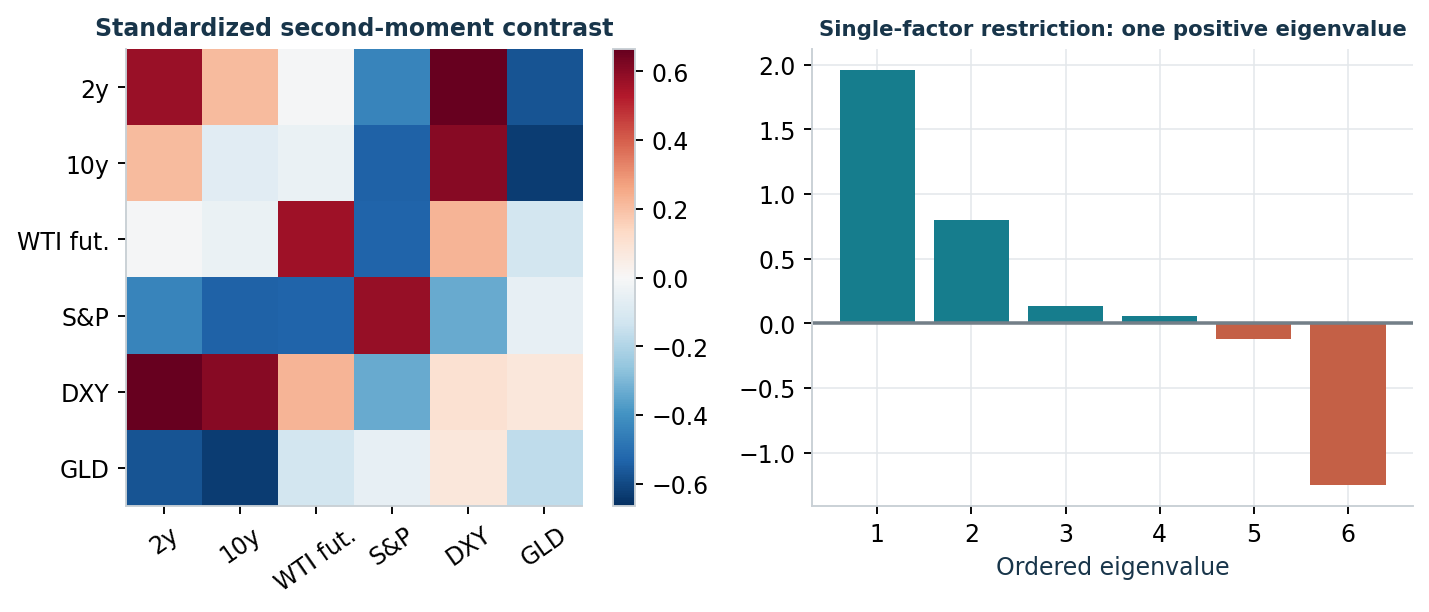

,specification,label,n_high,pooled_effect,weak_reference_variance_shift
0,CMT yields,10-year fitted Treasury,24,-0.1369,True
3,CMT yields,S&P 500,24,4.3132,True
9,CMT yields,WTI spot,24,13.2660,True
10,CMT yields,Brent spot,19,4.4046,True
20,Shift uncertain clocks,10-year fitted Treasury,23,-0.2447,True
23,Shift uncertain clocks,S&P 500,23,1.3372,True
29,Shift uncertain clocks,WTI spot,23,-19.1322,True
30,Shift uncertain clocks,Brent spot,18,-5.5730,True
40,Exclude adjacent controls,10-year fitted Treasury,23,-0.1758,False
43,Exclude adjacent controls,S&P 500,23,1.4818,False


In [7]:
rank = json.loads((OUT/'paper_rank.json').read_text())
print('Eigenvalues:', np.round(rank['eigenvalues'], 4))
print('Relative rank-one residual:', rank['rank_one_residual'])
display(Image(filename=str(OUT/'study_identification.png')))
robust = pd.read_csv(OUT/'paper_robustness.csv')
display(robust.loc[robust.variable.isin(['ten_year','sp500','wti_spot','brent_spot']),
                  ['specification','label','n_high','pooled_effect','weak_reference_variance_shift']])

## 8. Why the 2026 economy can produce a different table

The 2003 sample followed the dot-com collapse, September 11, corporate-accounting concerns and weak capital spending. It was a fragile recovery after the March–November 2001 recession, rather than a recession dated to the whole 2003 window. The [Federal Reserve’s February 2003 report](https://www.federalreserve.gov/boarddocs/hh/2003/february/ReportSection1.htm) records a 1.25% federal funds target and economic slack; [NBER’s chronology](https://www.nber.org/research/data/us-business-cycle-expansions-and-contractions) supplies the recession dates. Growth concerns and demand for safe assets provide an economic interpretation of the original negative yield and equity responses; the paper itself does not separately identify those mechanisms.

The US petroleum position is materially different. Annual crude production rises from **5.649 million barrels/day in 2003 to 13.662 in 2025**, an increase of 141.8%; June 2026 is separately observed at 13.792. Net imports of crude **and petroleum products** change from 11.238 million barrels/day in 2003 to net exports of 2.848 in 2025. As a share of products supplied, these are +56.1% and −13.7%, respectively. The US still has crude-only net imports: 1.309 million barrels/day in June 2026. These are different trade concepts. Sources: [EIA annual production](https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=MCRFPUS2&f=A), [net total petroleum imports](https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=MTTNTUS2&f=A), [products supplied](https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=MTTUPUS2&f=A), [monthly crude net imports](https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=MCRNTUS2&f=M) and [monthly production](https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=MCRFPUS2&f=M).

A larger domestic producer sector can offset some consumer and importing-firm losses, but it does not insulate US consumers from global oil prices. That is a plausible mechanism, not an estimated decomposition of the positive equity coefficient. EIA’s pre-conflict benchmark puts first-half 2025 Hormuz flows at 20.9 million barrels/day, about 20% of global petroleum-liquids consumption and one-quarter of maritime oil trade. These are **2025 exposure figures**, not September 2026 traffic estimates. [EIA prices and world-market exposure](https://www.eia.gov/energyexplained/oil-and-petroleum-products/prices-and-outlook.php); [World Oil Transit Chokepoints](https://www.eia.gov/international/content/analysis/special_topics/World_Oil_Transit_Chokepoints/).

Inflation and the expected rate path can also change the yield response. January 2003 headline/core CPI inflation was 2.6%/1.9% year over year; August 2026 was 3.4%/2.4%. August energy and gasoline prices were 16.3% and 27.4% above a year earlier. These observations support examining an energy-inflation channel without attributing all inflation to war. [BLS January 2003](https://www.bls.gov/news.release/archives/cpi_02212003.pdf); [BLS August 2026](https://www.bls.gov/news.release/archives/cpi_09112026.htm). BEA’s second estimate puts Q2 2026 real GDP growth at 1.5% at an annualized quarterly rate, following 2.1% in Q1, with private domestic final sales up 4.2% annualized. These are not year-over-year rates. [BEA release](https://www.bea.gov/news/2026/gdp-second-estimate-and-corporate-profits-2nd-quarter-2026).

The public CMT curve on 14 March 2003 was 1.56% at two years and 3.72% at ten years, a 2.16-point slope; the 15 September 2026 slope is only 0.33 points. This compares descriptive public curves, not identical fitted regression inputs. [Historical H.15 release](https://www.federalreserve.gov/releases/h15/20030317/). The 2026 bear flattening is consistent with a changed expected short-rate path, but ten-year yields also contain real-rate expectations, inflation compensation and term/liquidity premia. This analysis cannot separate those components.

The 16 September FOMC announcement at 14:00 ET raised the target range by 25 bp to 3.75–4.00%, effective 17 September. It is a scheduled macroeconomic confound inside the broad market window. The frozen CMT and fitted-curve snapshots end earlier, so their missing September 16 response cannot be inferred. [FOMC statement](https://www.federalreserve.gov/newsevents/pressreleases/monetary20260916a.htm); [implementation note](https://www.federalreserve.gov/newsevents/pressreleases/monetary20260916a1.htm). Different coefficients can consequently reflect economic exposure, news composition, instrument maturity, normalization and identification failure. The table alone cannot determine their relative contributions.

## 9. Free news connectors and duration-related language

**GDELT is the main free connector for the full historical window.** Its keyless DOC endpoint supports article discovery but can cap results at 250 and returned repeated rate limits during collection. The complete empirical feed instead uses GDELT’s public daily bulk event archive: all **259 daily files** for 1 January–16 September returned successfully. Iran actor/action-location filtering retains 1,807,433 event rows and 371,309 canonical source URLs. These are event records and linked sources, **not 371,309 downloaded article bodies**. Repeated actor-event rows are collapsed to one source URL per availability session. [GDELT data access](https://www.gdeltproject.org/data.html); [event data codebook](https://data.gdeltproject.org/documentation/GDELT-Data_Format_Codebook.pdf).

The Guardian’s free academic/noncommercial API is useful for full-text research, but needs a key and has a 500-request daily allowance. No key was available; the supplementary text corpus was obtained from the public publisher archive, not misdescribed as an API download. NewsAPI’s free developer tier offers 100 requests/day, a 24-hour delay and one month of searchable history, so it does not cover the entire January–September window. [Guardian access terms](https://open-platform.theguardian.com/access/); [NewsAPI plans](https://newsapi.org/pricing). Bulk GDELT is therefore the practical primary free source here, with publisher text as a context check.

The publisher collection discovers 1,893 URLs. Excluding 444 live/multimedia pages, 416 non-news pages and four failed downloads leaves 1,029 extracted documents; four bodies modified after the cutoff are excluded, leaving **1,025 documents, 917 war-relevant**. Relevance uses Iran and conflict/energy context in the headline or at least two body sentences. Classification then uses the headline, while preserving the full-body provenance and the later of publication/modification time. These retrieved bodies cannot reconstruct every original real-time article.

Every eligible publisher headline and every retained GDELT source URL receives a category. The duration distinction is operationalized as **cessation/reopening evidence versus continuing fighting/disruption**, with mixed, negotiation-only, attributed-statement and unclear cases explicit. Words suited to this conflict include Hormuz, tanker, blockade, shipping, reopening, missile, drone, strike, ceasefire and truce. Negation matters: “ceasefire collapses” differs from “ceasefire extended”; extending a ceasefire is not extending the war. Illustrative phrases explain rules, not additional observed news.

GDELT CAMEO 087 and descendants describe de-escalation, including declared/observed ceasefires, easing blockades, demobilization and retreat; roots 19/20 describe fighting/violence. Only records whose coded event date is zero to two days before archive entry enter daily counts. Older, future-dated or unknown-age mentions remain auditable but do not enter that signal. A source with both code types belongs to the mixed category and can contribute to both daily counts. [CAMEO manual](https://data.gdeltproject.org/documentation/CAMEO.Manual.1.1b3.pdf). Code 0871 can describe a declaration, so it cannot certify that hostilities ended. Iran-linked domestic violence, extraction errors, repeated wire stories and uneven English-language coverage can contaminate these measures.

Binary variables record **whether qualifying news is present**: major-war-news day, any retrieved war news, cessation-coded news and fighting-coded news. All 177 observed sessions contain some GDELT war-coded source material; the broad feed therefore provides no strict zero-war-news comparison. The Guardian has 20 zero-article sessions, which are outlet-level zeros only. Missing downloads would be missing coverage, not zero news. The paper’s H/L design uses major versus other news days instead.

This is target-specific interpretation of sentiment around conflict, not a calibrated probability that the war ends soon. An actual probability would require a fixed horizon, a verifiable termination definition, independent labels and out-of-sample calibration. One ongoing, right-censored conflict cannot supply those labels by itself. Generic positive language about a successful attack can coexist with continued fighting; negotiations need not mean cessation. No accuracy estimate or probability calibration is claimed.

{
  "guardian_items": 1025,
  "guardian_war_items": 917,
  "guardian_categories": {
    "Attributed statement/policy context": 583,
    "War context; duration unclear": 183,
    "Outside Iran-war scope": 108,
    "Continuing fighting/disruption language": 103,
    "Negotiation context without verified cessation": 28,
    "Cessation/reopening language": 16,
    "Mixed physical developments": 4
  },
  "gdelt_source_urls": 371309,
  "gdelt_categories": {
    "Other Iran-related code": 270997,
    "Fighting/violence code": 89710,
    "Cessation/truce/withdrawal code": 7711,
    "Mixed cessation and fighting codes": 2891
  },
  "news_sessions": 177,
  "sessions_with_any_gdelt_war_news": 177,
  "sessions_with_no_guardian_war_article": 20,
  "guardian_clock_states": {
    "pre_open": 288,
    "after_close": 265,
    "weekend": 250,
    "open": 203,
    "holiday": 19
  },
  "guardian_friday_sunday": 368,
  "interpretation": "Nominal physical-event/topic categories, not war-end probabilities or

,Publisher headline category,Items
0,Attributed statement/policy context,583
1,War context; duration unclear,183
2,Outside Iran-war scope,108
3,Continuing fighting/disruption language,103
4,Negotiation context without verified cessation,28
5,Cessation/reopening language,16
6,Mixed physical developments,4


,GDELT source category,URLs
0,Other Iran-related code,270997
1,Fighting/violence code,89710
2,Cessation/truce/withdrawal code,7711
3,Mixed cessation and fighting codes,2891


,cessation_sources,cessation_news,log_cessation_sources,fighting_sources,fighting_news,log_fighting_sources,gdelt_war_sources,any_gdelt_war_news,guardian_war_articles,any_guardian_war_news
count,177.0000,177.0000,177.0000,177.0000,177.0000,177.0000,177.0000,177.0000,177.0000,177.0000
mean,58.5763,1.0000,3.6129,514.8305,1.0000,5.8306,557.6384,1.0000,5.1808,0.8870
std,69.5358,0.0000,1.0058,611.5020,0.0000,0.8676,632.2764,0.0000,7.6590,0.3175
min,1.0000,1.0000,0.6931,47.0000,1.0000,3.8712,48.0000,1.0000,0.0000,0.0000
25%,20.0000,1.0000,3.0445,174.0000,1.0000,5.1648,193.0000,1.0000,1.0000,1.0000
50%,36.0000,1.0000,3.6109,321.0000,1.0000,5.7746,346.0000,1.0000,3.0000,1.0000
75%,75.0000,1.0000,4.3307,618.0000,1.0000,6.4281,663.0000,1.0000,6.0000,1.0000
max,502.0000,1.0000,6.2206,"4,505.0000",1.0000,8.4132,"4,609.0000",1.0000,62.0000,1.0000


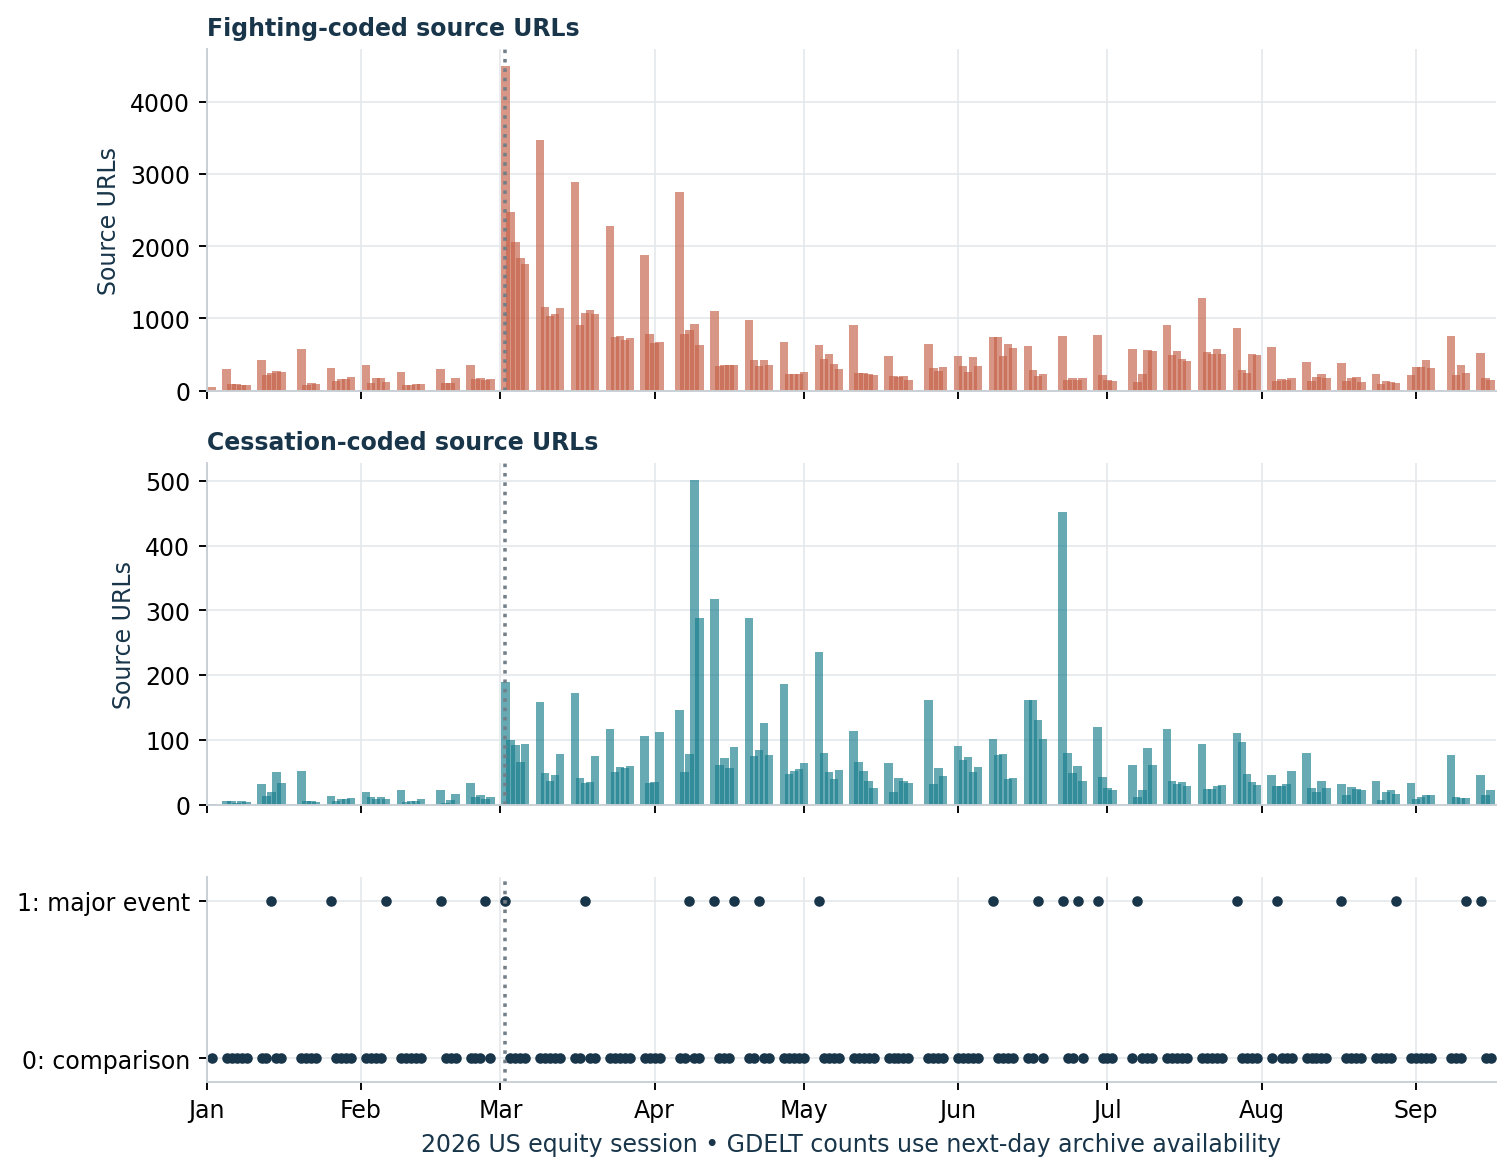

In [8]:
print(json.dumps(duration_summary, indent=2))
display(pd.DataFrame(duration_summary['guardian_categories'].items(), columns=['Publisher headline category','Items']))
display(pd.DataFrame(duration_summary['gdelt_categories'].items(), columns=['GDELT source category','URLs']))
coverage = pd.read_csv(OUT/'gdelt_bulk_coverage.csv')
assert len(coverage)==259 and coverage.status.astype(str).eq('200').all()
display(duration_daily.describe())
display(Image(filename=str(OUT/'study_news.png')))

## 10. Friday–Sunday news, market hours and next-session responses

The reference clock is the NYSE core session, **09:30–16:00 New York time**, using the actual 2026 holiday calendar and daylight-saving conversion. A pre-open or intraday item maps to the first scheduled close strictly after its timestamp; an item at or after the close maps to the next session. Friday before close can affect Friday; Friday after close, Saturday and Sunday usually map to Monday, or the next trading day after a holiday. A separate first-open clock and the following reaction session are retained. [NYSE hours and calendars](https://www.nyse.com/trade/hours-calendars).

For example, the February 28 Saturday outbreak maps to March 2; the April 7 announcement at 18:32 ET maps to April 8; the April 12 Sunday news maps to April 13. Known report times establish availability, not necessarily the first occurrence of the underlying event. Other date-only developments have uncertain intraday placement and are shifted one session in the sensitivity analysis. The reaction-window audit reports both the first mapped session’s daily change and the following session’s change, including explicit Friday–Sunday flags.

The publisher sample has 368 Friday–Sunday items and the Truth Social set 161. Of the latter, 128 appear during the equity session, 81 before open, 82 after close, 101 on weekends and 11 on holidays; 15 are Friday after-close posts. The two sources use different clocks: the publisher’s later publication/modification time and the post’s original timestamp. Neither necessarily equals first public information, particularly for reposts.

Cash-equity closure is not closure of every market. Standard WTI futures reopen Sunday evening at 18:00 ET and trade nearly around the clock with a daily break. Treasury CMT observations are based on indicative bids around 15:30 ET, while US equities close at 16:00. [CME WTI contract overview](https://www.cmegroup.com/education/courses/event-contracts-underlying-markets/wti-overview); [Treasury rate methodology](https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics). Daily labels cannot recover exact synchronous intraday responses, and this panel does not contain the opening quotes needed to separate overnight from intraday returns.

GDELT bulk dates provide daily archive information, not publisher timestamps. The conservative availability clock is **07:00 ET on the next calendar day**, then the first subsequent US close; this is no earlier than the archive’s documented next-morning availability. Consequently the empirical news model studies archive-availability associations. It must not silently assign that file to a tradable previous-day news signal.

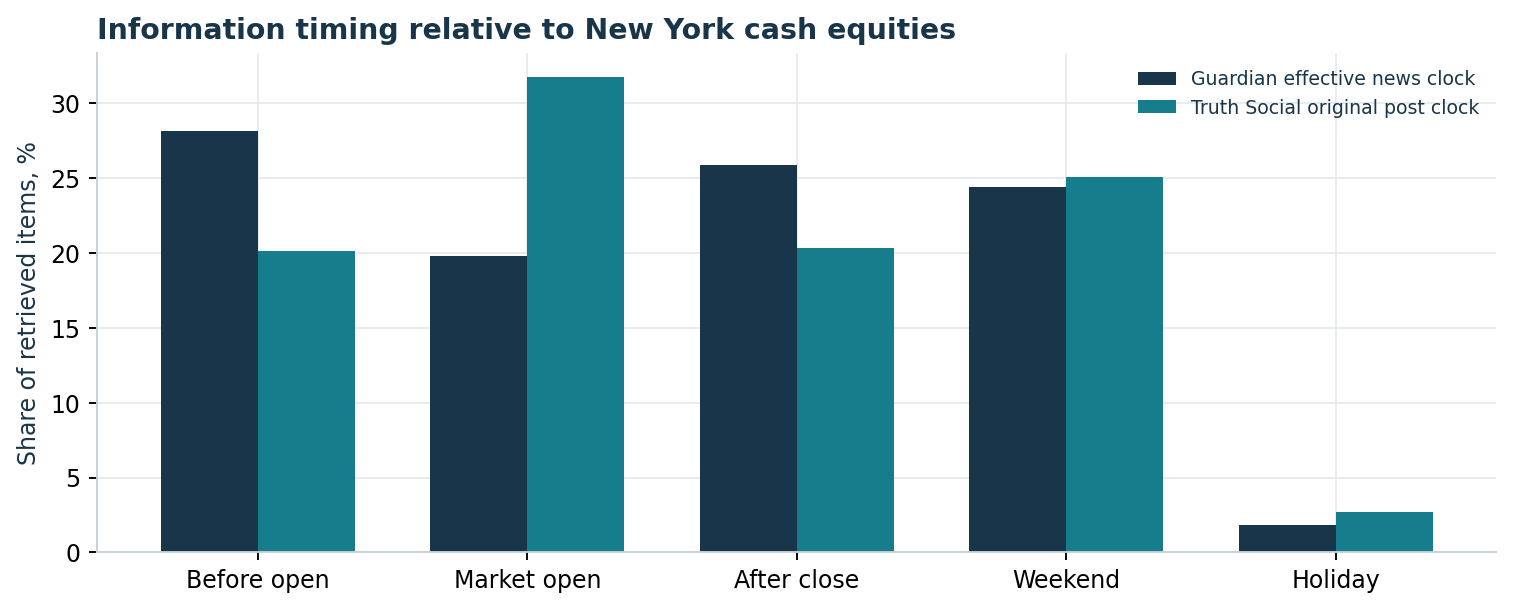

,event_date,cash_window,reaction_session,following_session,reaction_change,following_change,unit
10,2026-02-06,Intraday time uncertain,2026-02-06,2026-02-09,1.9696,0.4691,%
22,2026-02-28,Weekend; closed,2026-03-02,2026-03-03,0.0398,-0.9444,%
34,2026-04-12,Weekend; closed,2026-04-13,2026-04-14,1.0173,1.1783,%
42,2026-04-17,Intraday time uncertain,2026-04-17,2026-04-20,1.2040,-0.2374,%
50,2026-05-03,Weekend; closed,2026-05-04,2026-05-05,-0.4062,0.8120,%
54,2026-06-07,Weekend; closed,2026-06-08,2026-06-09,0.2978,-0.2576,%
70,2026-06-28,Weekend; closed,2026-06-29,2026-06-30,1.1750,0.7920,%
90,2026-08-28,07:00 ET report; pre-open,2026-08-28,2026-08-31,-0.2487,-0.3322,%
94,2026-09-11,Intraday time uncertain,2026-09-11,2026-09-14,0.8599,-0.4832,%
98,2026-09-13,Weekend; closed,2026-09-14,2026-09-15,-0.4832,-0.4495,%


,event_date,outcome,reaction_session,following_session,reaction_change,following_change,unit
28,2026-04-07,wti_spot,2026-04-08,2026-04-09,-16.0674,3.5874,%
29,2026-04-07,brent_spot,2026-04-08,2026-04-09,-11.6489,-2.5223,%
30,2026-04-07,sp500,2026-04-08,2026-04-09,2.5081,0.6170,%
31,2026-04-07,ten_year,2026-04-08,2026-04-09,-0.0354,0.0007,pp


,Equity state,Posts
0,open,128
1,weekend,101
2,after_close,82
3,pre_open,81
4,holiday,11


In [9]:
display(Image(filename=str(OUT/'study_timing.png')))
reactions = pd.read_csv(OUT/'event_reaction_windows.csv')
display(reactions.loc[reactions.friday_sunday & reactions.outcome.eq('sp500'),
 ['event_date','cash_window','reaction_session','following_session','reaction_change','following_change','unit']])
display(reactions.loc[reactions.event_date.eq('2026-04-07'),
 ['event_date','outcome','reaction_session','following_session','reaction_change','following_change','unit']])
display(pd.DataFrame(social_summary['equity_state_counts'].items(), columns=['Equity state','Posts']))

## 11. An alternative suited to ongoing conflict

A single war factor can combine expected duration, supply damage and risk aversion. The implemented alternative retains **two separate physical-news dimensions**, cessation-coded and fighting-coded source counts, rather than subtracting one from the other or forcing every article into a binary forecast. On the US session grid define $z_t^k=\Delta\log(1+N_t^k)/sd[\Delta\log(1+N_t^k)]$ for each category $k$. Scaling is retrospective over the available sample, not an out-of-sample trading calibration.

For each of eight financial outcomes, estimate cumulative responses from the preceding close to horizons $h=0,1,5$ using both news variables, their lags, a lagged outcome, log calendar-interval length, month effects and scheduled FOMC indicators. The estimation begins on March 2 to focus on active conflict. Price outcomes are cumulative simple percentage returns; yield outcomes and the oil spread are differences in their stated units. HAC inference uses 5+h lags, finite-sample correction and t inference. The 48 primary coefficients form one Benjamini–Hochberg adjustment family. This controls a multiple-testing criterion under its dependence conditions; it does not remove endogeneity.

None of the 48 coefficients has adjusted $q<0.05$; the smallest q is about **0.424**. This is limited evidence in a short noisy sample, not proof that war news has no market effect. Regressing the **preceding** session’s return on the same archive-news change provides 16 separate timing checks, with a lag two outcome control to avoid putting the dependent variable itself on the right side. Five survive that family’s adjustment: WTI/fighting, Brent/cessation, Brent/fighting, S&P/cessation and S&P/fighting. Significant movements before archive availability are consistent with already-incorporated public news, common shocks or reporting that follows markets. These checks prevent interpreting the fitted coefficients as causal or immediately tradable.

The more suitable causal research design would use independently verified **first-public-event timestamps** and narrow windows in matched-maturity oil futures, Treasury prices and equity futures. Separate documented cessation, supply interruption and renewed-fighting events; retain mixed/uncertain cases; distinguish Sunday futures reactions from Monday cash reactions; control or exclude overlapping CPI, FOMC and other scheduled releases. Labels should be assigned without viewing market returns and checked by independent annotators. Multiple historical conflicts and a declared endpoint would be needed to estimate and validate termination probabilities. Complete historical intraday quotes and reliable first-public timestamps were not acquired here, so that design is a proposal, not a claimed completed experiment.

Compared with the original single-variance-shift method, this design better matches the ongoing conflict’s multiple channels and timing. Its credibility would depend on unanticipated information, precise clocks and clean windows. The daily local projections provide a transparent empirical extension and a timing diagnostic; they do not automatically outperform the paper as causal identification.

,outcome,feature,horizon,coefficient,se,p_value,q_value,n,unit,first_date,last_date
2,wti_spot,cessation,0,0.1200,0.7398,0.8714,0.9295,137,%,2026-03-02,2026-09-15
3,wti_spot,fighting,0,1.1562,0.7751,0.1383,0.5305,137,%,2026-03-02,2026-09-15
4,wti_spot,cessation,1,-0.4224,0.8206,0.6076,0.9295,136,%,2026-03-02,2026-09-14
5,wti_spot,fighting,1,1.9303,0.9675,0.0482,0.4154,136,%,2026-03-02,2026-09-14
6,wti_spot,cessation,5,-0.2173,0.8520,0.7992,0.9295,132,%,2026-03-02,2026-09-08
7,wti_spot,fighting,5,3.7082,1.7777,0.0391,0.4154,132,%,2026-03-02,2026-09-08
10,brent_spot,cessation,0,-0.8057,0.7740,0.3002,0.8161,125,%,2026-03-02,2026-09-15
11,brent_spot,fighting,0,1.5261,0.9429,0.1084,0.5202,125,%,2026-03-02,2026-09-15
12,brent_spot,cessation,1,-2.0386,1.0064,0.0452,0.4154,124,%,2026-03-02,2026-09-14
13,brent_spot,fighting,1,2.8103,1.2234,0.0235,0.4154,124,%,2026-03-02,2026-09-14


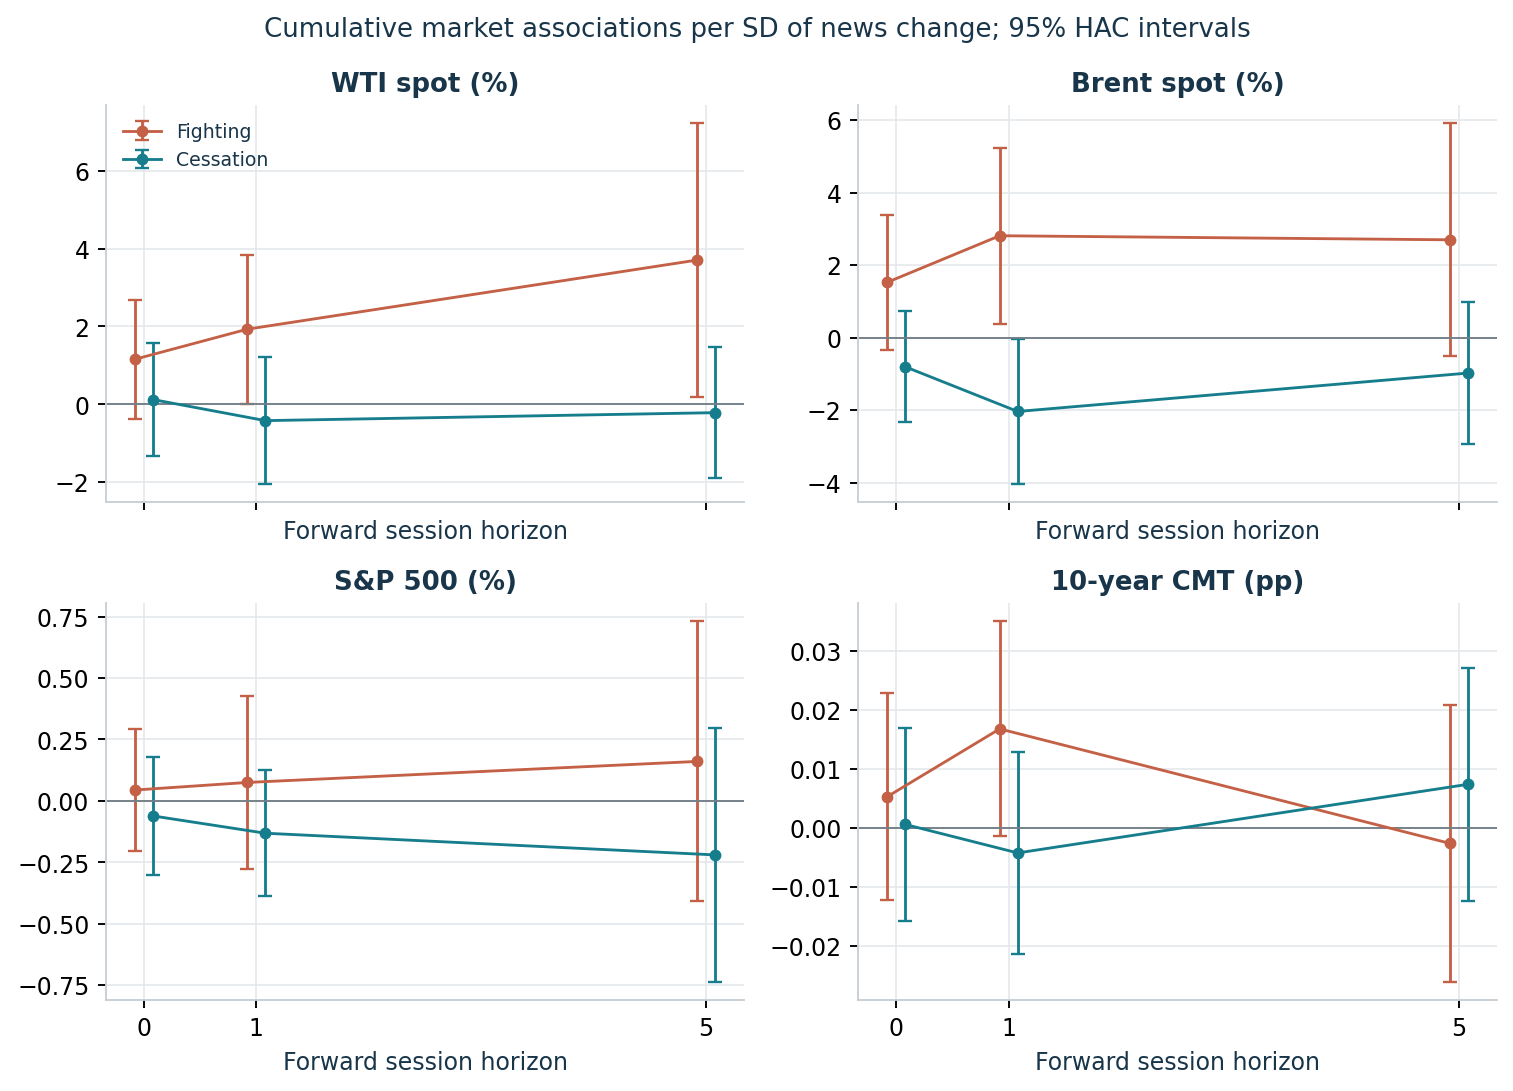

,outcome,feature,coefficient,p_value,q_value,n,unit
0,wti_spot,cessation,-1.8305,0.0393,0.1049,138,%
1,wti_spot,fighting,2.4073,0.0010,0.0154,138,%
8,brent_spot,cessation,-2.0068,0.0047,0.0188,123,%
9,brent_spot,fighting,2.6038,0.0037,0.0188,123,%
16,sp500,cessation,0.3438,0.0117,0.0375,138,%
17,sp500,fighting,-0.4134,0.0026,0.0188,138,%
24,two_year,cessation,0.0082,0.2019,0.3230,136,pp
25,two_year,fighting,-0.0102,0.1258,0.2516,136,pp
32,ten_year,cessation,-0.0054,0.2964,0.4311,136,pp
33,ten_year,fighting,-0.0015,0.8268,0.9321,136,pp


In [10]:
lp = pd.read_csv(OUT/'duration_local_projections.csv')
display(lp.loc[lp.horizon.ge(0), ['outcome','feature','horizon','coefficient','se','p_value','q_value','n','unit','first_date','last_date']])
display(Image(filename=str(OUT/'study_alternative.png')))
display(lp.loc[lp.horizon.eq(-1), ['outcome','feature','coefficient','p_value','q_value','n','unit']])
assert len(lp.loc[lp.horizon.ge(0)]) == 48
assert diagnostics['lp_primary_q_lt05'] == 0
assert diagnostics['lp_placebo_q_lt05'] == 5

## 12. Trump posts: platform, coverage and interpretation

The social corpus comes from the public [CNN Truth Social archive](https://ix.cnn.io/data/truth-social/truth_archive.json), with original-post links retained. The 2026 New York date window contains 5,697 archive records; 1,894 have empty readable text and are media records. Literal Iran-related keyword retrieval produces **403 candidate records with 388 distinct text strings**. All 403 IDs, texts and dates are checked against the raw snapshot; nine selected IDs are independently corroborated through the American Presidency Project archive. No complete 2026 X/Twitter corpus was obtained. Truth Social is therefore analyzed as Truth Social, with the X coverage gap explicit.

The candidate set includes 43 explicit repost cues, four attribution-prefix cases, three URL-only records and 16 records with untranscribed media. Eleven match a keyword only inside a URL; those are retrieval candidates, not verified Iran prose. Counts overlap and are not additive exclusions. Repeated wording at different IDs remains a publication record; duplicate text does not imply duplicate IDs. Media, implicit references, linked contents, deleted posts and source gaps prevent an “all posts” claim. A post’s timestamp does not establish that it introduced new information.

All retrieved candidates receive timing and nonexclusive literal subject flags after URL removal. There are 162 records with military/strike wording, 122 with shipping/blockade wording, 111 with negotiation/agreement wording, 85 with nuclear terms, 63 with energy-price terms and 15 with ceasefire/truce wording. These are corpus counts, not sentiment scores, independent events or verified claims. Negotiation and attack language may coexist. Complete row-level audits remain local; the notebook displays aggregate results and selected linked readings.

Sentiment interpretation follows the supplied literature’s distinction between **speaker, target and proposition**. Praise of a conversation concerns the conversation; a conditional threat is not an observed attack; a claimed cancellation does not establish permanent peace. Preserve negation, future tense, quoted/reposted material, emphasis and stated conditions. The selected readings below show how those distinctions affect the economic interpretation. No causal effect of an individual post, calibrated war-end probability, or numerical evaluation of an official or policy is asserted.

In [11]:
audit = json.loads((OUT/'social_timing_summary.json').read_text())
display(pd.DataFrame(audit['claim_cue_record_counts'].items(), columns=['Nonexclusive literal subject cue','Candidate records']))
print('Platform:', audit['platform'], '| Records:', audit['candidate_records'])
print('Friday–Sunday:', audit['friday_to_sunday_posts'], '| Friday after close:', audit['friday_after_close_posts'])
examples = [('2026-01-02', '115824439366264186', 'Conditional intervention tied to treatment of protesters. Future tense and the stated condition do not establish that intervention occurred.'), ('2026-01-12', '115884319075881590', 'A tariff announcement concerns trade restrictions, a separate channel from a physical interruption of crude supply.'), ('2026-02-04', '116013105630663812', 'Iran is one subject of a conversation with China’s president. Favorable language describes the conversation and relationship, rather than an observed end to conflict.'), ('2026-03-01', '116152251973821428', 'A conditional response to an anticipated Iranian action. Preserve the condition, future tense and emphasis when interpreting the statement.'), ('2026-04-01', '116329512466946656', 'A claimed ceasefire request, a Hormuz condition and continuing-attack language coexist. These propositions concern different outcomes and should be read separately.'), ('2026-05-03', '116512555123589170', 'A shipping-operation announcement appears alongside negotiation references. Navigation access and stated conditions matter for the oil-supply channel.'), ('2026-08-01', '117023461141824050', 'A claimed cancellation of a planned attack is linked to an agreement condition. It is not an unconditional statement that the conflict has ended.'), ('2026-09-01', '117196950497702512', 'The account reports strikes around Hormuz and states a condition for a further response. Keep the reported claim distinct from the prospective condition.'), ('2026-09-07', '117232304514057261', 'A forecast about oil and gasoline prices depends on a future war outcome. It is an attributed price claim, not an observed market effect.')]
display(pd.DataFrame([[date,'Truth Social',f'https://truthsocial.com/@realDonaldTrump/{post}',reading]
                      for date,post,reading in examples],columns=['Date ET','Platform','Original URL','Interpretation']))

,Nonexclusive literal subject cue,Candidate records
0,ceasefire_truce,15
1,negotiations_agreement,111
2,cessation_cancellation,18
3,continuation_extension,33
4,strikes_military,162
5,shipping_blockade,122
6,nuclear,85
7,energy_prices,63
8,trade_sanctions,19
9,humanitarian_civilian,18


Platform: Truth Social | Records: 403
Friday–Sunday: 161 | Friday after close: 15


,Date ET,Platform,Original URL,Interpretation
0,2026-01-02,Truth Social,https://truthsocial.com/@realDonaldTrump/11582...,Conditional intervention tied to treatment of ...
1,2026-01-12,Truth Social,https://truthsocial.com/@realDonaldTrump/11588...,A tariff announcement concerns trade restricti...
2,2026-02-04,Truth Social,https://truthsocial.com/@realDonaldTrump/11601...,Iran is one subject of a conversation with Chi...
3,2026-03-01,Truth Social,https://truthsocial.com/@realDonaldTrump/11615...,A conditional response to an anticipated Irani...
4,2026-04-01,Truth Social,https://truthsocial.com/@realDonaldTrump/11632...,"A claimed ceasefire request, a Hormuz conditio..."
5,2026-05-03,Truth Social,https://truthsocial.com/@realDonaldTrump/11651...,A shipping-operation announcement appears alon...
6,2026-08-01,Truth Social,https://truthsocial.com/@realDonaldTrump/11702...,A claimed cancellation of a planned attack is ...
7,2026-09-01,Truth Social,https://truthsocial.com/@realDonaldTrump/11719...,The account reports strikes around Hormuz and ...
8,2026-09-07,Truth Social,https://truthsocial.com/@realDonaldTrump/11723...,A forecast about oil and gasoline prices depen...


## 13. Lessons from all seven local social-text readings

The supplied materials jointly support transparent collection, preserving originals, careful normalization, target-aware interpretation and domain-specific validation. Generic TextBlob or VADER polarity does not measure conflict duration. Removing stopwords or punctuation indiscriminately can remove negation and emphasis. A trained model also requires a genuine labeled evaluation set; published benchmark accuracy cannot be transferred to this corpus by assertion. No human-labeled Iran-war sentiment benchmark was created in this study.

The full set of locally supplied social-media readings and their application is listed below. Bibliographic records for the research papers are [Bagheri and Islam](https://arxiv.org/abs/1711.10377), [Psomakelis et al.](https://www.scitepress.org/PublishedPapers/2014/50753/50753.pdf), and [Carvalho and Plastino](https://link.springer.com/article/10.1007/s10462-020-09895-6). The latter appeared online in 2020 and in the 2021 journal volume. The unattributed teaching presentations are identified by title; file metadata alone is not treated as proof of authorship or publication date.

In [12]:
display(pd.DataFrame([('Course presentation, undated', 'Twitter sentiment analysis overview', 'Keyword retrieval is a sampling rule; historical API instructions do not guarantee complete current archives.'), ('Yalin Yener, 2020', 'Step by Step: Twitter Sentiment Analysis in Python', 'Keep original text and a separate normalized field; distinguish reposts from duplicate IDs; vocabulary clouds do not validate sentiment.'), ('Bagheri and Islam, 2017', 'Sentiment analysis of twitter data', 'Short text, abbreviations and context challenge dictionary methods; query proportions are not accuracy estimates.'), ('Psomakelis et al., 2014', 'Comparing Methods for Twitter Sentiment Analysis', 'Representation and contextual features matter; their manually labeled benchmark does not establish accuracy on Iran-war statements.'), ('Carvalho and Plastino, 2021; online 2020', 'On the evaluation and combination of state-of-the-art features in Twitter sentiment analysis', 'Preserve negation and expressive features; evaluate feature combinations and domain transfer. Their binary benchmarks do not resolve neutral or mixed war text.'), ('Supplied presentation, undated', 'Exploring Differences in the Sentiment Analysis Tools using Twitter Data concerning Autism Awareness', 'Separate VADER from trained classifiers and use human validation. TN/(FP+TN) is specificity, not precision; VADER proportions are not probabilities.'), ('Stanford-derived course slides, undated', 'Sentiment Analysis', 'Identify the attitude holder, target and textual unit; irony and mixed targets make a generic positive/negative label unsuitable for war duration.')], columns=['Reference','Title','Application']))

,Reference,Title,Application
0,"Course presentation, undated",Twitter sentiment analysis overview,Keyword retrieval is a sampling rule; historic...
1,"Yalin Yener, 2020",Step by Step: Twitter Sentiment Analysis in Py...,Keep original text and a separate normalized f...
2,"Bagheri and Islam, 2017",Sentiment analysis of twitter data,"Short text, abbreviations and context challeng..."
3,"Psomakelis et al., 2014",Comparing Methods for Twitter Sentiment Analysis,Representation and contextual features matter;...
4,"Carvalho and Plastino, 2021; online 2020",On the evaluation and combination of state-of-...,Preserve negation and expressive features; eva...
5,"Supplied presentation, undated",Exploring Differences in the Sentiment Analysi...,Separate VADER from trained classifiers and us...
6,"Stanford-derived course slides, undated",Sentiment Analysis,"Identify the attitude holder, target and textu..."


## 14. Investment decision, limitations and reproducibility

My decision is an **illustrative 10% allocation to a Treasury bill with about three months remaining**, retaining the diversified core. The weight is a stated risk budget, not an optimized or backtested output of the text models. At the 15 September three-month constant-maturity benchmark of 4.11%, simple three-month carry is approximately $4.11\%\times0.25=1.0275\%$ on that allocation, or **0.103 percentage points** on the whole portfolio before costs. A CMT rate is a benchmark, not an executable bill quote. A first-order duration approximation of 0.25 years implies about a 0.25% price loss for a 100-bp yield rise, or 0.025 percentage points at portfolio level; this is a mark-to-market illustration and differs from holding a bill to maturity.

Short duration reduces interest-rate exposure but is not a complete hedge against an energy-price shock. The wide physical oil spread does not establish convergence; the fragile IV estimates do not support leveraged hedge ratios; and archive-availability correlations do not justify a news-timing trade. A portfolio with a specific oil-consumption liability could require a matched physical or futures hedge, which is outside the portfolio and data specified here. No trade was placed.

The strongest empirical conclusions are descriptive market trends and documented identification limits. The calendar is retrospective and incomplete; event clocks are sometimes uncertain; data are revised snapshots; closing times differ; public proxies do not exactly reproduce proprietary 2003 instruments; GDELT codes can misclassify events; repeated coverage is not independent news; and the publisher corpus is one English-language outlet. The estimated positive variance shift is weak, the rank-one restriction fits poorly, and macroeconomic developments can change nuisance variance. None of these limitations is repaired by a larger count of articles.

The [public repository](https://github.com/ph2606/FRE-GY-7871A-Assignment3) contains acquisition code, the fully executed notebook, source-linked research design, focused tests, pinned dependencies and an AI-use disclosure. Raw articles, posts, downloaded data, generated CSV files and internal notes are not committed. Cached source manifests retain URLs, coverage, retrieval information and hashes. The notebook recomputes the classifications, timing audit, Tables 1–3, bootstrap diagnostics, alternative models and figures, and checks input hashes. A later uncached download may change a historical observation or article body even at the same cutoff; saved outputs preserve the analyzed snapshot. The PDF is a separate submission artifact.

In [13]:
assert diagnostics['main_pairs'] == 23
assert diagnostics['main_weak_rows'] == diagnostics['main_available_outcomes'] == 19
assert duration_summary['guardian_items'] == 1025
assert duration_summary['gdelt_source_urls'] == 371309
assert social_summary['candidate_records'] == 403
for name, digest in diagnostics['input_sha256'].items():
    assert hashlib.sha256((ROOT/name).read_bytes()).hexdigest() == digest
display(pd.DataFrame(diagnostics['input_sha256'].items(), columns=['Input','SHA256']))
print('Saved results reflect the declared snapshot; all verification assertions passed.')

,Input,SHA256
0,data/processed/market_levels.csv,fff788376ac9e0ba436ec766f0e66c22dbf71fd36d4692...
1,data/processed/offrun_yields.csv,bd46d33754f9b0238e374afe93ab59a14b1557efd9faf3...
2,data/processed/duration_daily.csv,6cba311549db6f5d5f5ab562f8a509231c46c7decd2fa2...
3,data/processed/gdelt_iran_events.csv,f103a0f2b132f120255f005ceac8052b17bacd748ff05d...
4,data/processed/social_candidates.csv,addb2f87477ebccf8867dce3916e417bc8c09420beb75c...


Saved results reflect the declared snapshot; all verification assertions passed.
